In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [3]:
train_df.shape
test_df.shape

(270000, 14)

In [4]:
train_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
train_df.describe()


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [7]:
train_df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [8]:
train_df.fillna(train_df.mean(numeric_only=True), inplace=True)

In [9]:
train_df["Heart Disease"].unique()

array(['Presence', 'Absence'], dtype=object)

In [10]:
train_df["Heart Disease"] = train_df["Heart Disease"].map({
    "Presence":1,
    "Absence":0
})

In [11]:
train_df["Heart Disease"].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

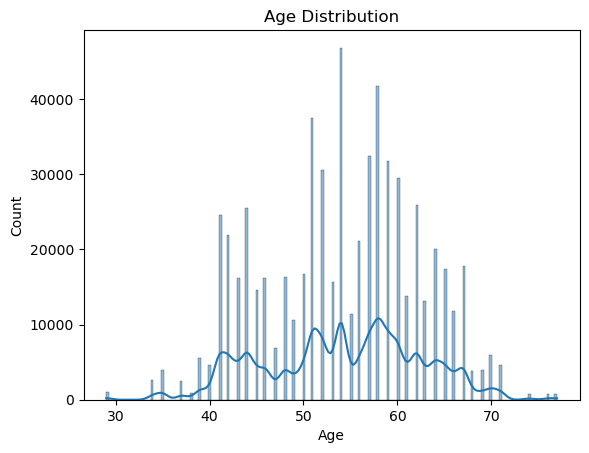

In [12]:
sns.histplot(train_df['Age'], kde=True)
plt.title("Age Distribution")
plt.savefig("Age_distribution.png")
plt.show()

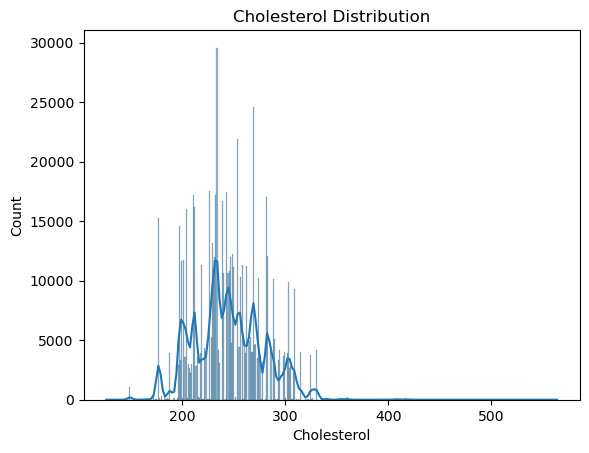

In [13]:
sns.histplot(train_df['Cholesterol'], kde=True)
plt.title("Cholesterol Distribution")
plt.savefig("Cholesterol_distribution.png")
plt.show()


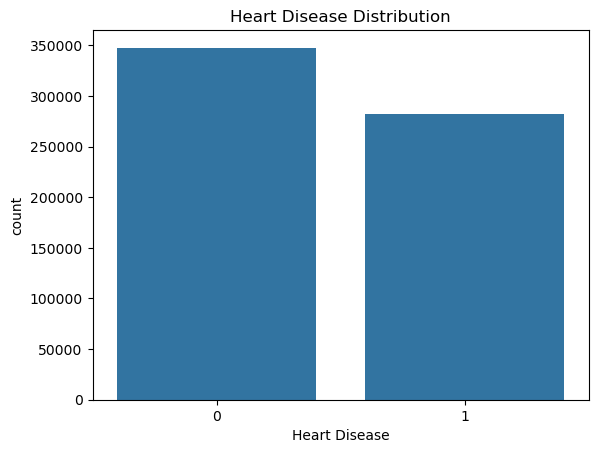

In [14]:
sns.countplot(x='Heart Disease', data=train_df)
plt.title("Heart Disease Distribution")
plt.savefig("Heart_disease_distribution.png")
plt.show()


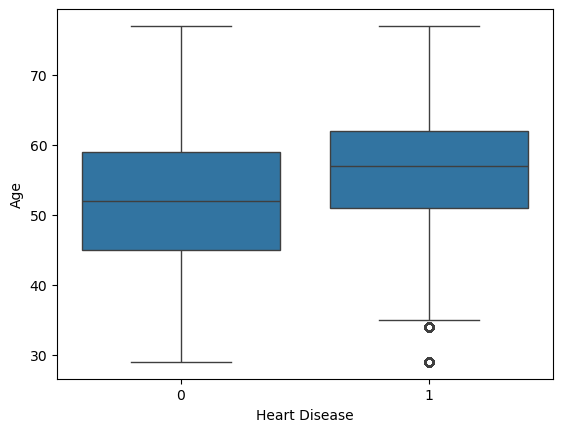

In [15]:
sns.boxplot(x='Heart Disease', y='Age', data=train_df)
plt.savefig("heartdieases.png")
plt.show()

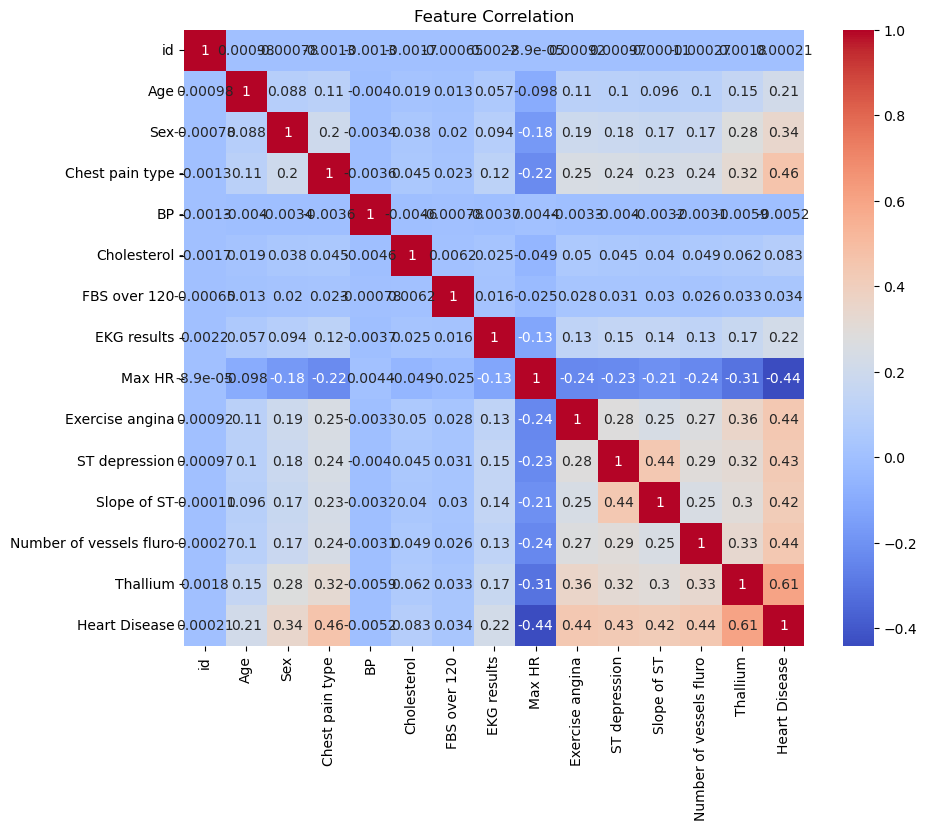

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.savefig("Feature_correlation.png")
plt.show()


In [17]:
X = train_df.drop("Heart Disease", axis=1)
y = train_df["Heart Disease"]

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(X_train.shape)
print(X_val.shape)

(504000, 14)
(126000, 14)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

In [21]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
log_pred = log_model.predict(X_val_scaled)

In [26]:
rf_pred = rf_model.predict(X_val)

In [27]:
knn_pred = knn_model.predict(X_val_scaled)

In [28]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_val, log_pred))

Logistic Regression Accuracy: 0.8847698412698413


In [29]:
print("Random Forest Accuracy:",
      accuracy_score(y_val, rf_pred))

Random Forest Accuracy: 0.8835714285714286


In [30]:
print("KNN Accuracy:",
      accuracy_score(y_val, knn_pred))

KNN Accuracy: 0.8719603174603174


In [31]:
confusion_matrix(y_val, rf_pred)

array([[62634,  6875],
       [ 7795, 48696]])

In [32]:
print(classification_report(y_val, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [33]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importances
})

feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
13,Thallium,0.174885
3,Chest pain type,0.144716
8,Max HR,0.113611
12,Number of vessels fluro,0.087292
0,id,0.078211
10,ST depression,0.069205
5,Cholesterol,0.063900
1,Age,0.061208
9,Exercise angina,0.057087
11,Slope of ST,0.055954


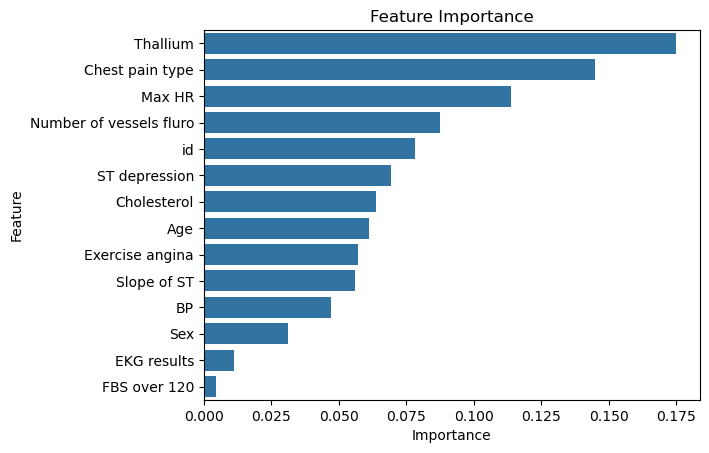

In [34]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.sort_values(by='Importance', ascending=False)
)

plt.title("Feature Importance")
plt.savefig("Feature_importance.png")
plt.show()


In [35]:
import pandas as pd

# Scale test data
test_scaled = scaler.transform(test_df)

# Convert back to DataFrame to keep column names
test_scaled = pd.DataFrame(test_scaled, columns=test_df.columns)

# Make predictions
test_predictions = rf_model.predict(test_scaled)

In [36]:
test_predictions = rf_model.predict(test_df)

In [37]:
submission = pd.DataFrame({
    "Prediction": test_predictions
})

In [38]:
submission.head()

,Prediction
0,1
1,0
2,1
3,0
4,0


In [39]:
importance = rf_model.feature_importances_

features = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

features = features.sort_values(by="Importance", ascending=False)

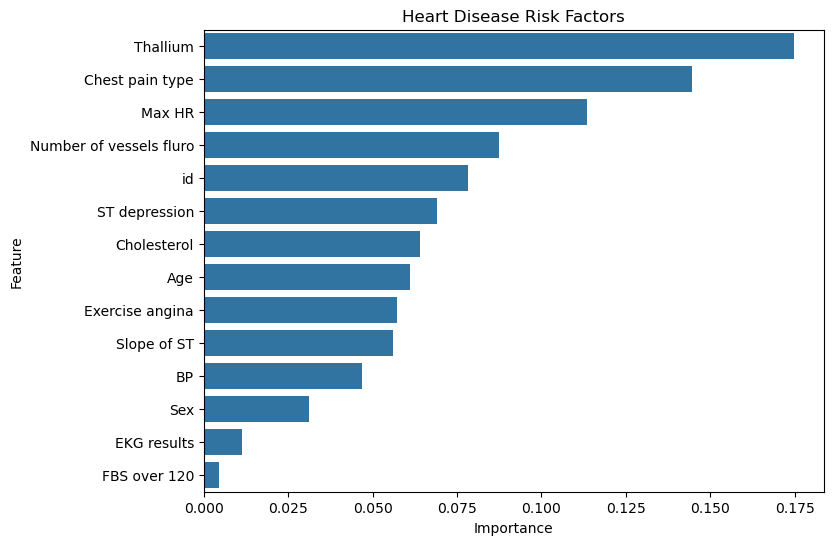

In [40]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=features
)

plt.title("Heart Disease Risk Factors")
plt.savefig("Hear_Disease_risk_factor.png")
plt.show()

In [41]:
accuracy_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],
    "Accuracy": [log_acc, rf_acc, knn_acc]
})

accuracy_df


Logistic Regression Accuracy: 0.8847698412698413
Random Forest Accuracy: 0.8835714285714286
KNN Accuracy: 0.8719603174603174


In [42]:
accuracy_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],
    "Accuracy": [log_acc, rf_acc, knn_acc]
})

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.884770
1,Random Forest,0.883571
2,KNN,0.871960


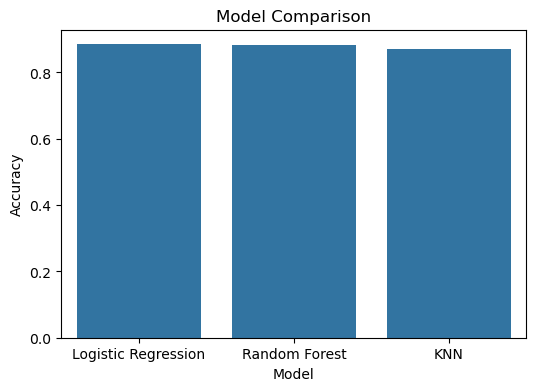

In [44]:
plt.figure(figsize=(6,4))

sns.barplot(x="Model", y="Accuracy", data=accuracy_df)

plt.title("Model Comparison")
plt.savefig("Model_Comparison.png")
plt.show()

In [45]:
best_model = accuracy_df.loc[accuracy_df["Accuracy"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Logistic Regression
Accuracy                0.88477
Name: 0, dtype: object


In [46]:
print("Random Forest Accuracy: {:.2f}%".format(rf_acc * 100))

Random Forest Accuracy: 88.36%
